In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import stats
import pickle
import json
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
# dataset09 = baseClasses.Data(path="/Users/jcapo/cernbox/DUNE-IFIC/Software/rtd/pdhd/ana/2025-09-12_HP_calib_data")
# dataset10 = baseClasses.Data(path="/Users/jcapo/cernbox/DUNE-IFIC/Software/rtd/pdhd/ana/2025-10-12_HP_calib_data")
dataset_hp = baseClasses.Data(path="/Users/jcapo/cernbox/DUNE-IFIC/Software/rtd/pdhd/ana/hp_res")

In [3]:
# mask = (
#     ((dataset_hp.data.index > pd.Timestamp("2025-12-11 11:25:00").tz_localize("Europe/Zurich")))
# )

# dataset_hp.data = dataset_hp.data.loc[mask]
# dataset_hp.err = dataset_hp.err.loc[mask]

In [4]:
print(dataset_hp.data.head())

                              TE0001     TE0002     TE0003     TE0004  \
Unnamed: 0                                                              
2025-12-11 01:00:00+01:00  76.600583  76.576826  76.604643  76.583932   
2025-12-11 01:01:00+01:00  76.600722  76.577203  76.604700  76.584229   
2025-12-11 01:02:00+01:00  76.600454  76.576789  76.604740  76.584036   
2025-12-11 01:03:00+01:00  76.600569  76.576948  76.604573  76.583943   
2025-12-11 01:04:00+01:00  76.600696  76.576558  76.604318  76.583562   

                              TE0005     TE0006      TE0007      TE0008  \
Unnamed: 0                                                                
2025-12-11 01:00:00+01:00  76.615316  76.591443  292.505259  292.560098   
2025-12-11 01:01:00+01:00  76.615871  76.592159  292.505320  292.560687   
2025-12-11 01:02:00+01:00  76.615731  76.591883  292.505261  292.560549   
2025-12-11 01:03:00+01:00  76.615532  76.591597  292.506203  292.561518   
2025-12-11 01:04:00+01:00  76.615455  

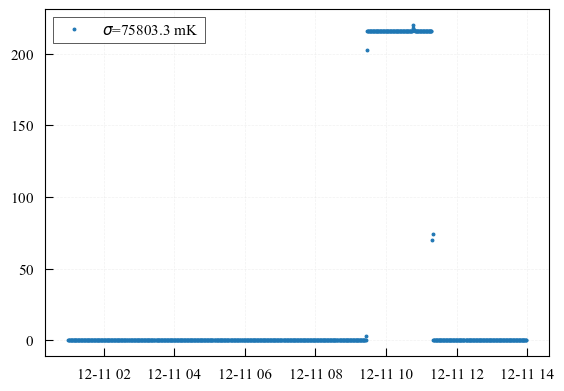

In [6]:
plt.plot(dataset_hp.data.index, dataset_hp.data['TE0025'] - dataset_hp.data['TE0026'], marker='.', linestyle="", label=fr'$\sigma$={1e3*(dataset_hp.data['TE0025'] - dataset_hp.data['TE0026']).std():.1f} mK')
# plt.xlim(pd.Timestamp("2025-12-11 11:25:00").tz_localize("Europe/Zurich"))
plt.legend()

In [6]:
hp_res = systemClasses.System(dataset_hp, "HP-RES")

Initializing HP-RES Sensors: 100%|██████████| 48/48 [00:03<00:00, 13.01sensor/s]


In [7]:
# hp_res09.calibrate("HP_LAB_CALIB", ref=8813)
# hp_res10.calibrate("HP_LAB_CALIB", ref=8813)
hp_res.calibrate("HP_LAB_CALIB", ref=8813)

Equalizing HP-RES Sensors: 100%|██████████| 48/48 [00:01<00:00, 29.65sensor/s]
Calibrating HP-RES Sensors - Calibration Name: HP_LAB_CALIB: 100%|██████████| 48/48 [00:00<00:00, 87.04sensor/s] 


In [8]:
print(hp_res.sensors.keys())

dict_keys([8848, 8847, 8846, 8845, 8844, 8843, 8842, 8841, 8840, 8839, 8838, 8837, 8836, 8835, 8834, 8833, 8832, 8831, 8830, 8829, 8828, 8827, 8826, 8825, 8824, 8823, 8822, 8821, 8820, 8819, 8818, 8817, 8816, 8815, 8814, 8813, 8860, 8859, 8858, 8857, 8856, 8855, 8854, 8853, 8852, 8851, 8850, 8849])


In [9]:
# hp_res09.makeProfiles(tini=datetime.datetime(2025, 12, 9, 18, 0, 0),
#                    tend=datetime.datetime(2025, 12, 9, 20, 0, 0))
# hp_res10.makeProfiles(tini=datetime.datetime(2025, 12, 10, 2, 0, 0),
#                    tend=datetime.datetime(2025, 12, 10, 4, 0, 0))
hp_res.makeProfiles(tini=pd.Timestamp("2025-12-11 11:30:00").tz_localize("Europe/Zurich").to_pydatetime(),
                       tend=pd.Timestamp("2025-12-11 14:00:00").tz_localize("Europe/Zurich").to_pydatetime())

In [10]:
print(hp_res.profiles)

     X       Y   Z        name       temp       err
0  NaN  5969.0 NaN  PDHD-HP-48  76.510006  0.000387
1  NaN  5851.0 NaN  PDHD-HP-47  76.511391  0.000410
2  NaN  5733.0 NaN  PDHD-HP-46  76.509956  0.000435
3  NaN  5615.0 NaN  PDHD-HP-45  76.511042  0.000470
4  NaN  5497.0 NaN  PDHD-HP-44  76.509285  0.000535
5  NaN  5379.0 NaN  PDHD-HP-43  76.507796  0.000515
6  NaN  5143.0 NaN  PDHD-HP-42  76.511600  0.000503
7  NaN  4907.0 NaN  PDHD-HP-41  76.510337  0.000508
8  NaN  4671.0 NaN  PDHD-HP-40  76.510278  0.000462
9  NaN  4435.0 NaN  PDHD-HP-39  76.508675  0.000406
10 NaN  4199.0 NaN  PDHD-HP-38  76.509159  0.000387
11 NaN  3963.0 NaN  PDHD-HP-37  76.507913  0.000336
12 NaN  3727.0 NaN  PDHD-HP-36  76.513604  0.000519
13 NaN  3491.0 NaN  PDHD-HP-35  76.512435  0.000523
14 NaN  3255.0 NaN  PDHD-HP-34  76.511616  0.000528
15 NaN  3019.0 NaN  PDHD-HP-33  76.511819  0.000563
16 NaN  2783.0 NaN  PDHD-HP-32  76.511316  0.000556
17 NaN  2547.0 NaN  PDHD-HP-31  76.509396  0.000548
18 NaN  2311

<ErrorbarContainer object of 3 artists>

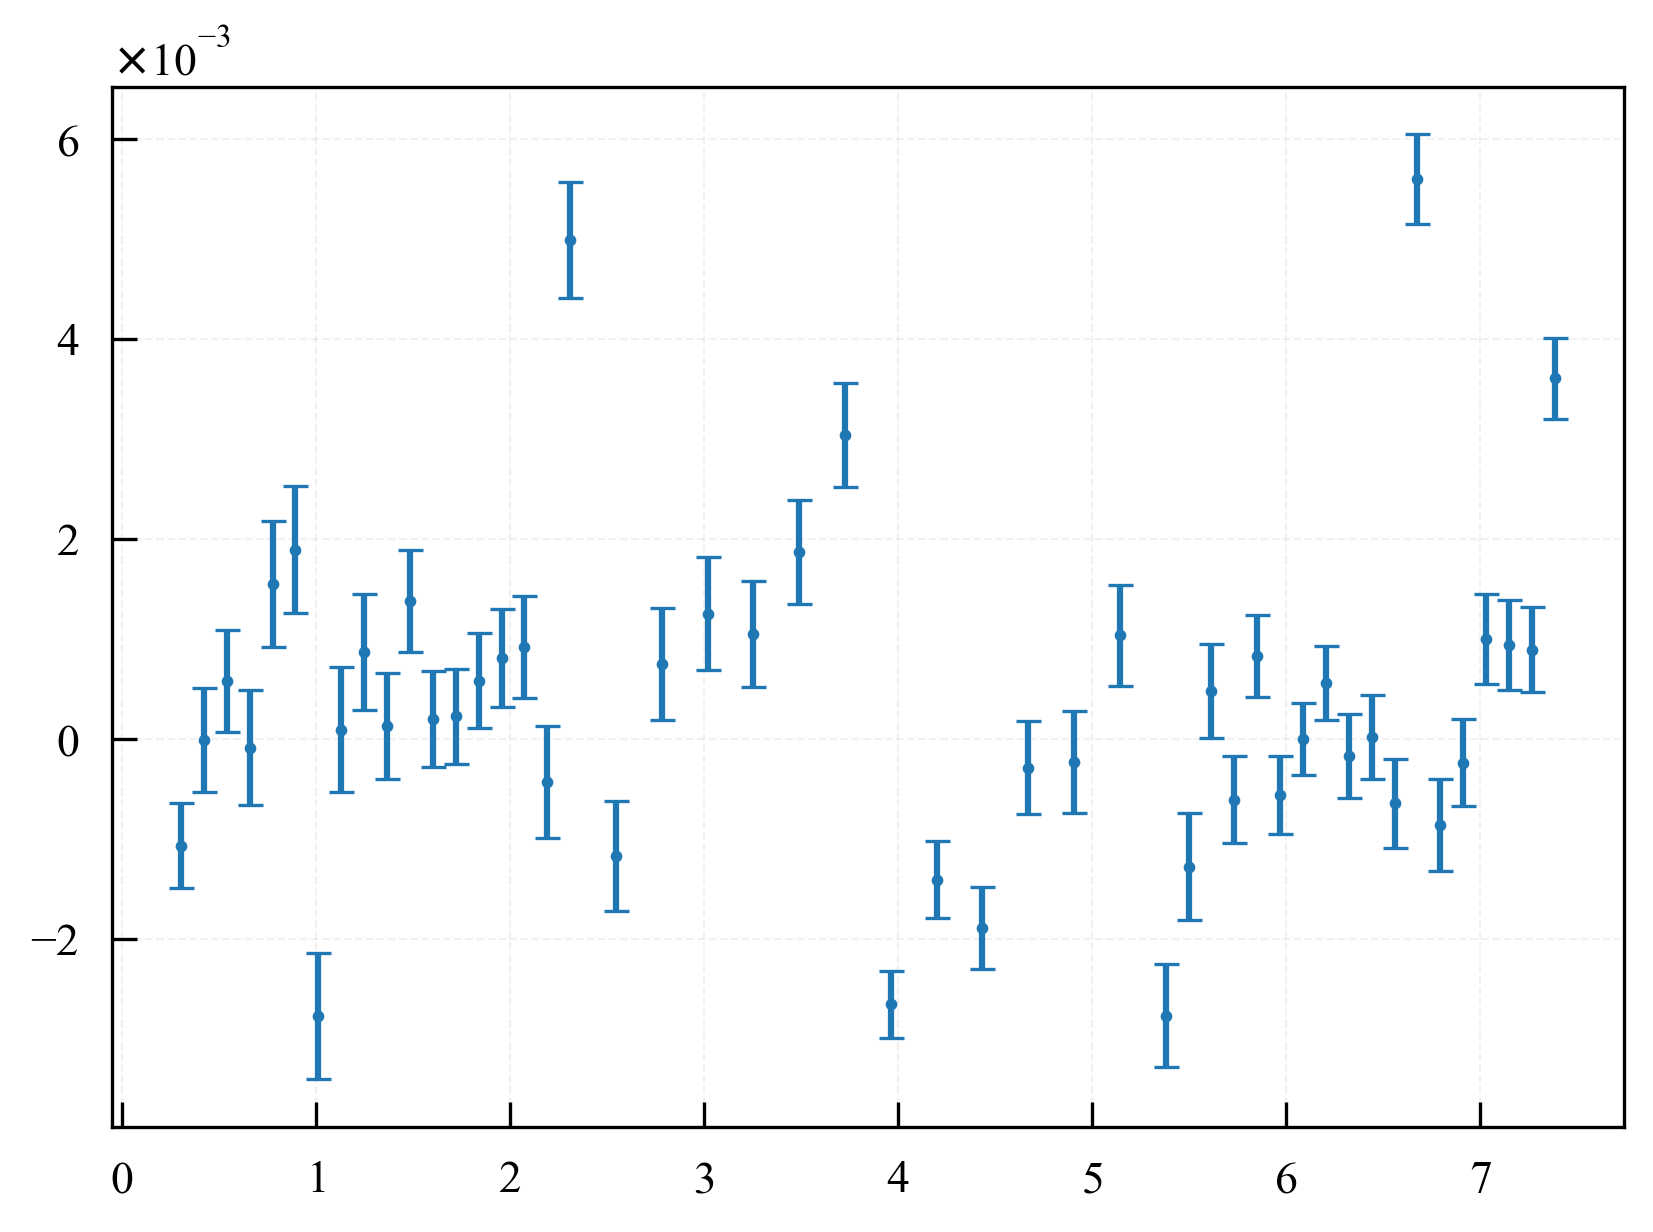

In [11]:
# plt.errorbar(
#     1e-3*hp_res09.profiles["Y"].values,
#     hp_res09.profiles["temp"].values - hp_res09.profiles["temp"].values[-1],
#     yerr=hp_res09.profiles["err"].values,
#     fmt="."
# )
# plt.errorbar(
#     1e-3*hp_res10.profiles["Y"].values,
#     hp_res10.profiles["temp"].values - hp_res10.profiles["temp"].values[-1],
#     yerr=hp_res10.profiles["err"].values,
#     fmt="."
# )
plt.errorbar(
    1e-3*hp_res.profiles["Y"].values,
    hp_res.profiles["temp"].values - hp_res.profiles["temp"].values[-1],
    yerr=hp_res.profiles["err"].values,
    fmt="."
)
# plt.ylim(76.5,76.750)

In [12]:
path_cern_rcalib = "/Users/jcapo/cernbox/RTDdata/calib/CERNRCalib.json"
cern_rcalib = json.load(open(path_cern_rcalib))
cern_rcalib["s1"] = [0.0, 0.0]

baseline = pd.read_csv("/Users/jcapo/cernbox/DUNE-IFIC/Software/rtd/pdhd/ana/mapping/baseline.csv")

In [13]:
print(baseline.head())

           DCS-ID   SC-ID  BOARD  SLOT SYSTEM    NAME   CAL-ID W-CABLE  \
0  47890261082394  TE0001    1.0   1.0  TGRAD  TGRAD1  39666.0     1.1   
1  47890277859610  TE0002    1.0   1.0  TGRAD  TGRAD2  39665.0     1.1   
2  47890294636826  TE0003    1.0   1.0  TGRAD  TGRAD3  39664.0     1.1   
3  47890311414042  TE0004    1.0   1.0  TGRAD  TGRAD4  39667.0     1.1   
4  47890328191258  TE0005    1.0   1.0  TGRAD  TGRAD5  39661.0     1.1   

   FLANGE  CHAN       X       Y      Z COMMENT COMMENT2  
0  14.4.1   1.0  1514.0  7385.0  861.0     NaN      NaN  
1  14.4.1   2.0  1514.0  7267.0  861.0     NaN      NaN  
2  14.4.1   3.0  1514.0  7149.0  861.0     NaN      NaN  
3  14.4.1   4.0  1514.0  7031.0  861.0     NaN      NaN  
4  14.4.1   5.0  1514.0  6913.0  861.0     NaN      NaN  


In [14]:
result1 = {}
cnt = 0
for key, values in cern_rcalib.items():
    result1[key] = (np.mean(values), np.std(values), baseline.iloc[cnt]["Y"])
    cnt += 1

In [15]:
result1 = pd.DataFrame(result1).T

Text(0.5, 0, 'Position (m)')

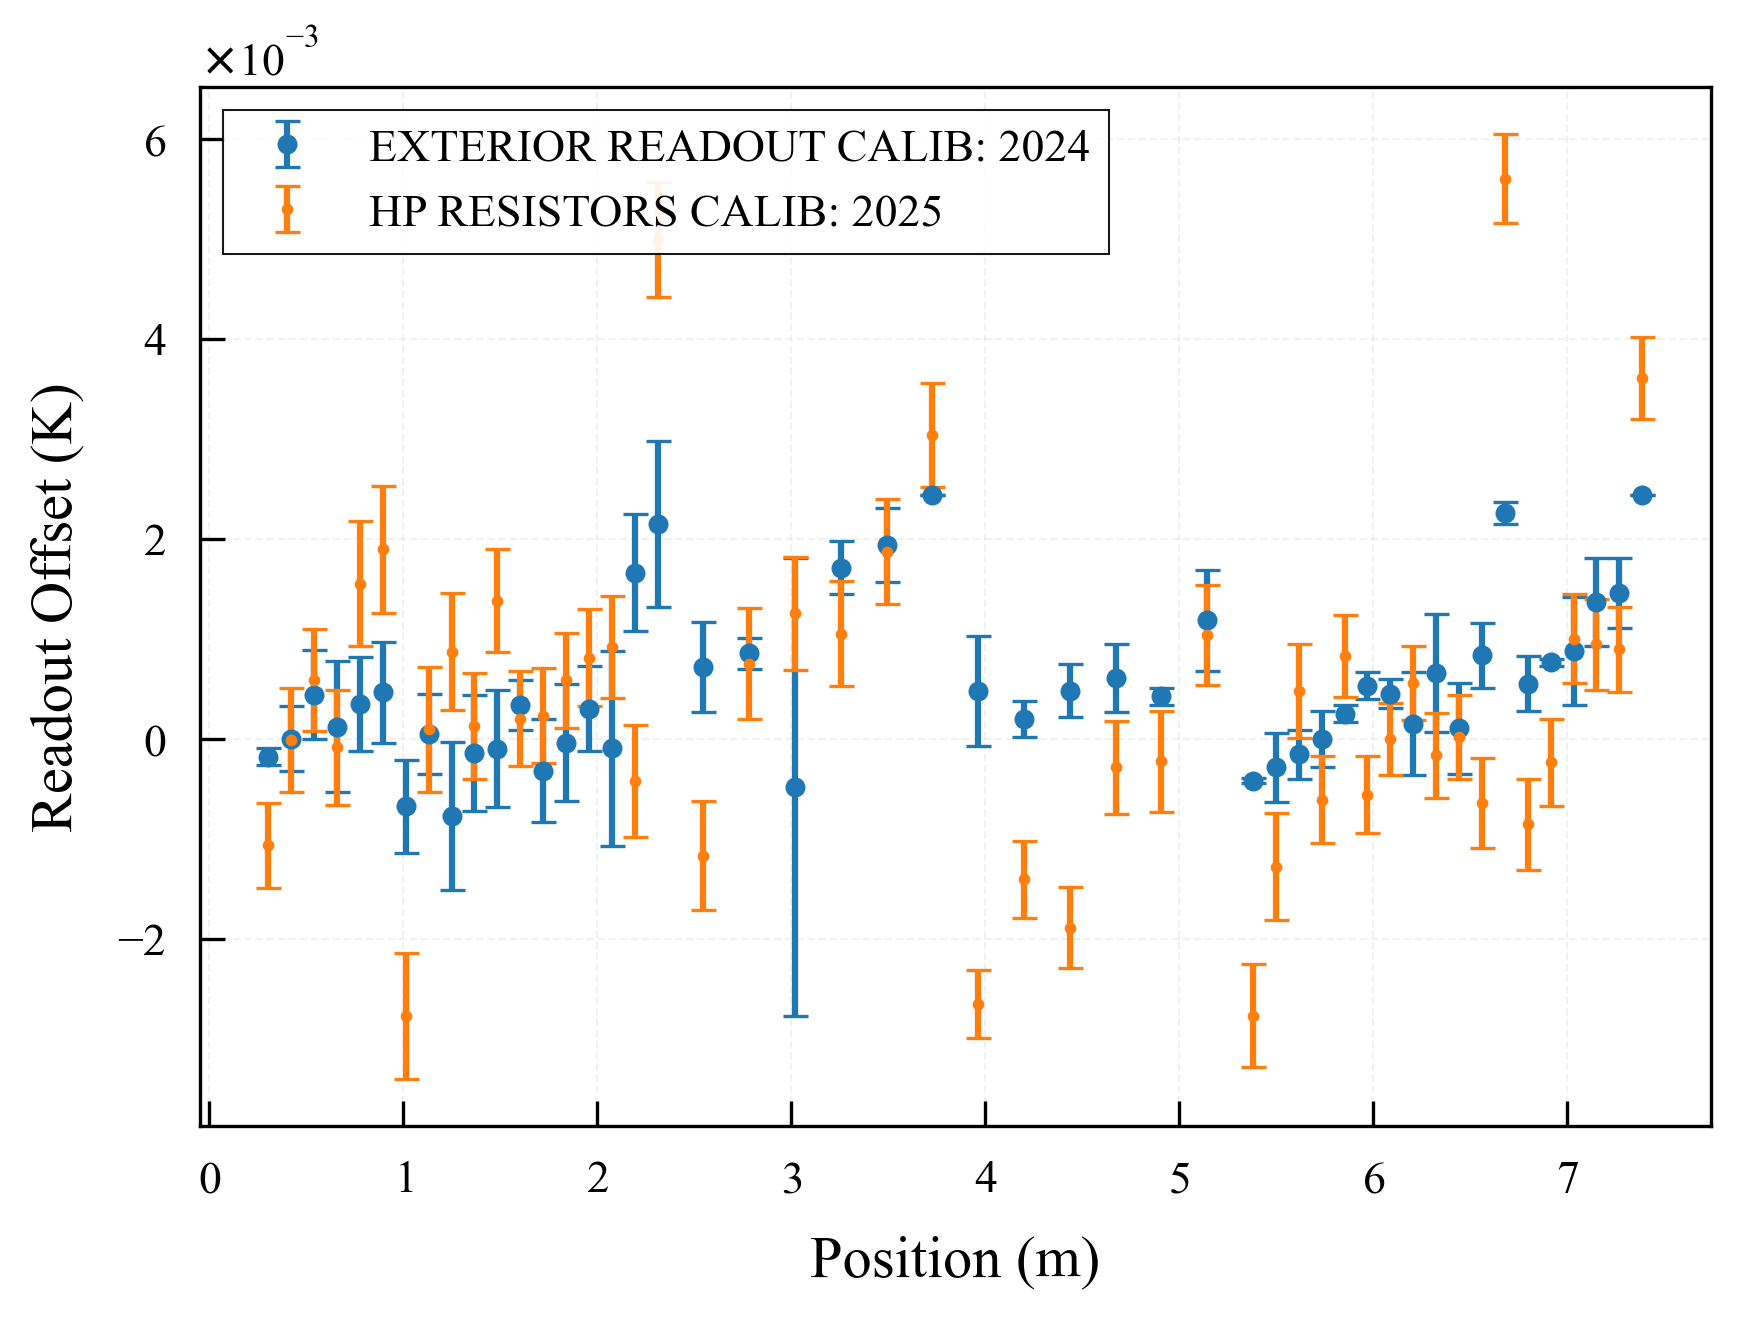

In [48]:
fig, axes = plt.subplots()
axes.errorbar(
    1e-3*result1[2], -1e-3*(result1[0] - result1[0].iloc[-2]), yerr=1e-3*result1[1], fmt="o",
    label="EXTERIOR READOUT CALIB: 2024"
    )

axes.errorbar(
    1e-3*hp_res.profiles["Y"].values,
    hp_res.profiles["temp"].values - hp_res.profiles["temp"].values[-1],
    yerr=hp_res.profiles["err"].values,
    fmt=".",
    label="HP RESISTORS CALIB: 2025"
)
axes.legend()
axes.set_ylabel("Readout Offset (K)")
axes.set_xlabel("Position (m)")
# plt.ylim(76.5,76.750)

In [8]:
hp_laboratory_calib = pd.read_csv("/Users/jcapo/cernbox/DUNE-IFIC/Software/rtd/pdhd/ana/2025-09-12_HP_calib_data/calibration_matrix_offsets.csv")

In [9]:
print(hp_laboratory_calib)

    Unnamed: 0  PDHD-HP-13  PDHD-HP-14  PDHD-HP-15  PDHD-HP-16  PDHD-HP-17  \
0   PDHD-HP-13    0.000000   -0.027318    0.002503    0.009007    0.007712   
1   PDHD-HP-14    0.027318    0.000000    0.029820    0.036324    0.035030   
2   PDHD-HP-15   -0.002503   -0.029820    0.000000    0.006504    0.005209   
3   PDHD-HP-16   -0.009007   -0.036324   -0.006504    0.000000   -0.001295   
4   PDHD-HP-17   -0.007712   -0.035030   -0.005209    0.001295    0.000000   
5   PDHD-HP-18    0.029947    0.002629    0.032450    0.038954    0.037659   
6   PDHD-HP-19    0.031700    0.004383    0.034203    0.040707    0.039413   
7   PDHD-HP-20    0.002848   -0.024469    0.005351    0.011855    0.010561   
8   PDHD-HP-21    0.014065   -0.013252    0.016568    0.023072    0.021778   
9   PDHD-HP-22   -0.014207   -0.041525   -0.011704   -0.005201   -0.006495   
10  PDHD-HP-23   -0.005846   -0.033164   -0.003343    0.003161    0.001866   
11  PDHD-HP-24    0.002088   -0.025229    0.004591    0.011095  

In [10]:
with open("/Users/jcapo/cernbox/RTDdata/calib/all/poff_2024-12-03_113500_2024-12-03_114500.pkl", "rb") as f:
    test = pickle.load(f)

In [34]:
results = {}
df = {}
for index, row in hp_laboratory_calib.iterrows():
    sensor_id = f"88{row['Unnamed: 0'].split('-')[-1]}"
    cc = row["PDHD-HP-13"]
    cc_err = 0
    df[(sensor_id)] = {"cc": cc*1e3, "cc_err": cc_err}
df = pd.DataFrame(df).T
results[8813] = df

In [ ]:
# with open("/Users/jcapo/cernbox/RTDdata/calib/HP_RESISTORS_TGRAD/lab_calib.pkl", "wb") as f:
#     pickle.dump(results, f)

In [12]:
dataset_cold = baseClasses.Data()

In [13]:
mask = (
    ((dataset_cold.data.index > datetime.datetime(2024, 3, 1)) & (dataset_cold.data.index < datetime.datetime(2024, 8, 1)))
)

dataset_cold.data = dataset_cold.data.loc[mask]
dataset_cold.err = dataset_cold.err.loc[mask]

In [14]:
tgrad = systemClasses.System(dataset_cold, "TGRAD")

Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing TGRAD Sensors: 100%|██████████| 48/48 [00:07<00:00,  6.56sensor/s]


In [101]:
tgrad.calibrate("LAR2018_TREE")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.64sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2018_TREE: 100%|██████████| 48/48 [00:00<00:00, 113.26sensor/s]

ERROR: SensorID (40530) not found in calibration (LAR2018_TREE)
ERROR: SensorID (40529) not found in calibration (LAR2018_TREE)


In [107]:
tgrad.makeProfiles(
    tini=datetime.datetime(2024, 6, 2, 9, 30),
    tend=datetime.datetime(2024, 6, 2, 10)
)

In [108]:
print(tgrad.profiles)

         X       Y      Z     name       temp       err
0   1514.0  7385.0  861.0   TGRAD1  87.650955  0.005127
1   1514.0  7267.0  861.0   TGRAD2  87.639611  0.003796
2   1514.0  7149.0  861.0   TGRAD3  87.646031  0.002833
3   1514.0  7031.0  861.0   TGRAD4  87.641436  0.002343
4   1514.0  6913.0  861.0   TGRAD5  87.667827  0.001715
5   1514.0  6795.0  861.0   TGRAD6  87.648800  0.001730
6   1514.0  6677.0  861.0   TGRAD7  87.653500  0.001538
7   1514.0  6559.0  861.0   TGRAD8  87.656582  0.002289
8   1514.0  6441.0  861.0   TGRAD9  87.655849  0.002149
9   1514.0  6323.0  861.0  TGRAD10  87.672342  0.002371
10  1514.0  6205.0  861.0  TGRAD11  87.689999  0.002051
11  1514.0  6087.0  861.0  TGRAD12  87.660328  0.002027
12  1514.0  5969.0  861.0  TGRAD13  87.661763  0.001783
13  1514.0  5851.0  861.0  TGRAD14  87.660550  0.001362
14  1514.0  5733.0  861.0  TGRAD15  87.660458  0.001409
15  1514.0  5615.0  861.0  TGRAD16  87.646189  0.000942
16  1514.0  5497.0  861.0  TGRAD17  87.657998  0

In [109]:
cold_profile = tgrad.profiles.set_index("Y").sort_index()
hp_profile = hp_res.profiles.set_index("Y").sort_index()

In [110]:
print(cold_profile.head())
print(hp_profile.head())

            X      Z     name       temp       err
Y                                                 
305.0  1514.0  861.0  TGRAD48  87.649358  0.000756
423.0  1514.0  861.0  TGRAD47  87.646719  0.000822
541.0  1514.0  861.0  TGRAD46  87.649294  0.000825
659.0  1514.0  861.0  TGRAD45  87.646448  0.000827
777.0  1514.0  861.0  TGRAD44  87.641083  0.001117
        X   Z        name       temp       err
Y                                             
305.0 NaN NaN  PDHD-HP-13  76.509498  0.000427
423.0 NaN NaN  PDHD-HP-14  76.510551  0.000520
541.0 NaN NaN  PDHD-HP-15  76.511148  0.000510
659.0 NaN NaN  PDHD-HP-16  76.510478  0.000576
777.0 NaN NaN  PDHD-HP-17  76.512116  0.000626


48 48


(-0.02, 0.03)

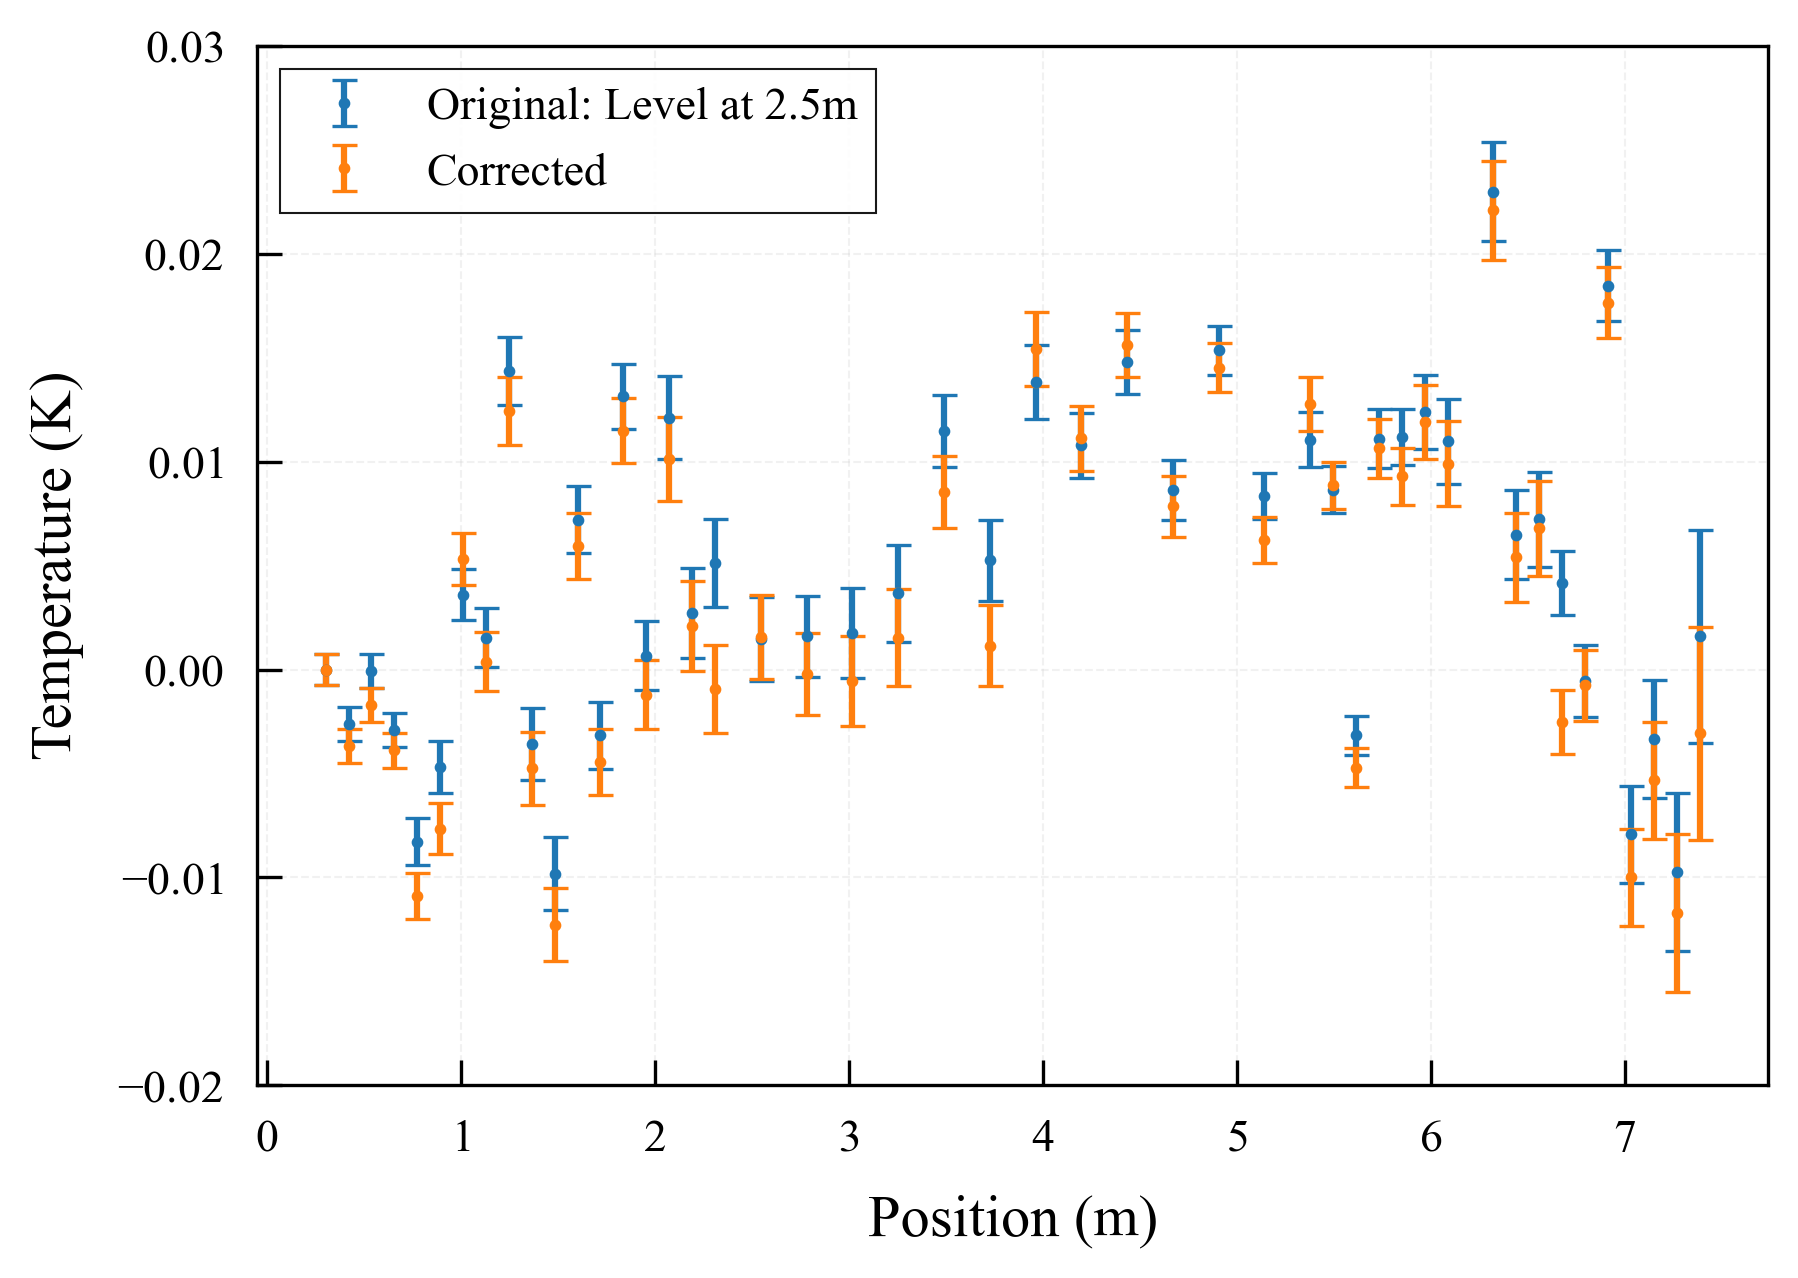

In [111]:
print(len(cold_profile), len(hp_profile))

fig, axes = plt.subplots()
axes.errorbar(
    1e-3*cold_profile.index.values,
    cold_profile["temp"].values - cold_profile["temp"].values[0],
    yerr=cold_profile["err"].values,
    fmt=".",
    color="tab:blue",
    label="Original: Level at 2.5m"
)

axes.errorbar(
    1e-3*cold_profile.index.values,
    (cold_profile["temp"] - (hp_profile["temp"] - hp_profile["temp"].values[-1])).values - (cold_profile["temp"] - (hp_profile["temp"] - hp_profile["temp"].values[-1])).values[0],
    yerr=cold_profile["err"].values,
    fmt=".",
    linestyle=None,
    color="tab:orange",
    label="Corrected"
)
axes.legend()
axes.set_xlabel("Position (m)")
axes.set_ylabel("Temperature (K)")
axes.set_ylim(-0.02,0.03)
# fig.set_size_inches(4,2.4)

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:07<00:00,  6.24sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG:  54%|█████▍    | 26/48 [00:00<00:00, 69.58sensor/s]

ERROR: SensorID (99999) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 71.64sensor/s]


ERROR: SensorID (40530) not found in calibration (LAR2023_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LAR2023_TREE_AVG)
23 48


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.04sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG:  46%|████▌     | 22/48 [00:00<00:00, 102.14sensor/s]

...

ERROR: SensorID (99999) not found in calibration (LN2022_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LN2022_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 101.18sensor/s]


ERROR: SensorID (40530) not found in calibration (LN2022_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LN2022_TREE_AVG)


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:07<00:00,  6.71sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2018_TREE: 100%|██████████| 48/48 [00:00<00:00, 93.82sensor/s]


ERROR: SensorID (40530) not found in calibration (LAR2018_TREE)
ERROR: SensorID (40529) not found in calibration (LAR2018_TREE)


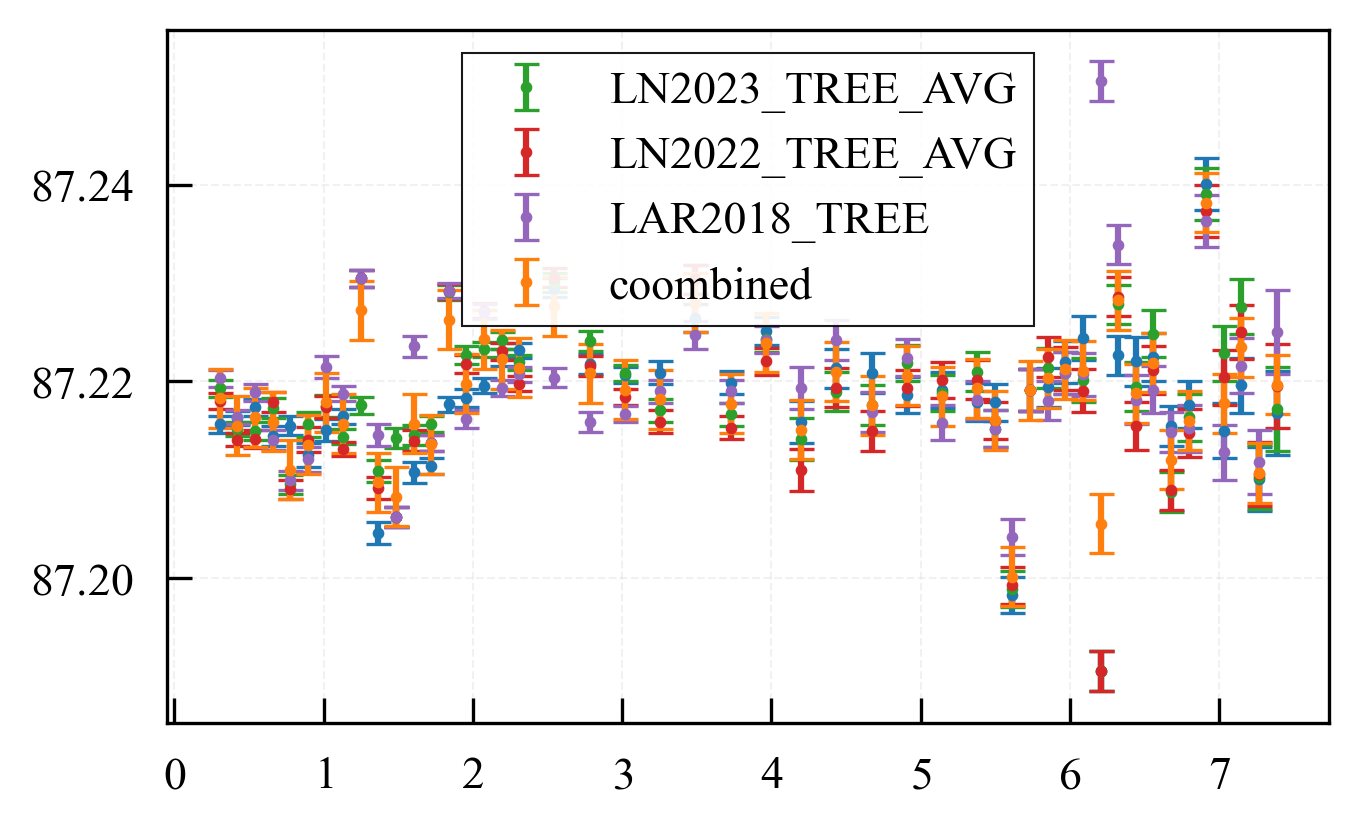

In [135]:
tgrad.calibrate("LAR2023_TREE_AVG")
tgrad.makeProfiles(
    tini=datetime.datetime(2024, 5, 2, 9, 30),
    tend=datetime.datetime(2024, 5, 2, 10, 0)
)
cold_profile = tgrad.profiles.set_index("Y")
hp_profile = hp_res.profiles.set_index("Y")
cold_profile = cold_profile.loc[(cold_profile.index<3500)]

lar2023 = tgrad.profiles.set_index("Y")

print(len(cold_profile), len(hp_profile))

fig, axes = plt.subplots()
axes.errorbar(
    1e-3*tgrad.profiles["Y"].values,
    tgrad.profiles["temp"].values,
    yerr=tgrad.profiles["err"].values,
    fmt=".",
    color="tab:blue"
)

tgrad.calibrate("LN2023_TREE_AVG")
tgrad.makeProfiles(
    tini=datetime.datetime(2024, 5, 2, 9, 30),
    tend=datetime.datetime(2024, 5, 2, 10, 0)
)

ln23 = tgrad.profiles.set_index("Y")

axes.errorbar(
    1e-3*tgrad.profiles["Y"].values,
    tgrad.profiles["temp"].values,
    yerr=tgrad.profiles["err"].values,
    fmt=".",
    label="LN2023_TREE_AVG",
    color="tab:green"
)

tgrad.calibrate("LN2022_TREE_AVG")
tgrad.makeProfiles(
    tini=datetime.datetime(2024, 5, 2, 9, 30),
    tend=datetime.datetime(2024, 5, 2, 10, 0)
)

ln22 = tgrad.profiles.set_index("Y")

axes.errorbar(
    1e-3*tgrad.profiles["Y"].values,
    tgrad.profiles["temp"].values,
    yerr=tgrad.profiles["err"].values,
    fmt=".",
    label="LN2022_TREE_AVG",
    color="tab:red"
)

tgrad.calibrate("LAR2018_TREE")
tgrad.makeProfiles(
    tini=datetime.datetime(2024, 5, 2, 9, 30),
    tend=datetime.datetime(2024, 5, 2, 10, 0)
)

lar2018 = tgrad.profiles.set_index("Y")

axes.errorbar(
    1e-3*tgrad.profiles["Y"].values,
    tgrad.profiles["temp"].values,
    yerr=tgrad.profiles["err"].values,
    fmt=".",
    label="LAR2018_TREE",
    color="tab:purple"
)

axes.errorbar(
    1e-3*lar2023.index.values,
    (lar2023["temp"] + ln22["temp"] + ln23["temp"] + lar2018["temp"]).values/4,
    yerr=3e-3,
    fmt=".",
    label="coombined",
    color="tab:orange"
)

fig.set_size_inches(5,3)
plt.legend()

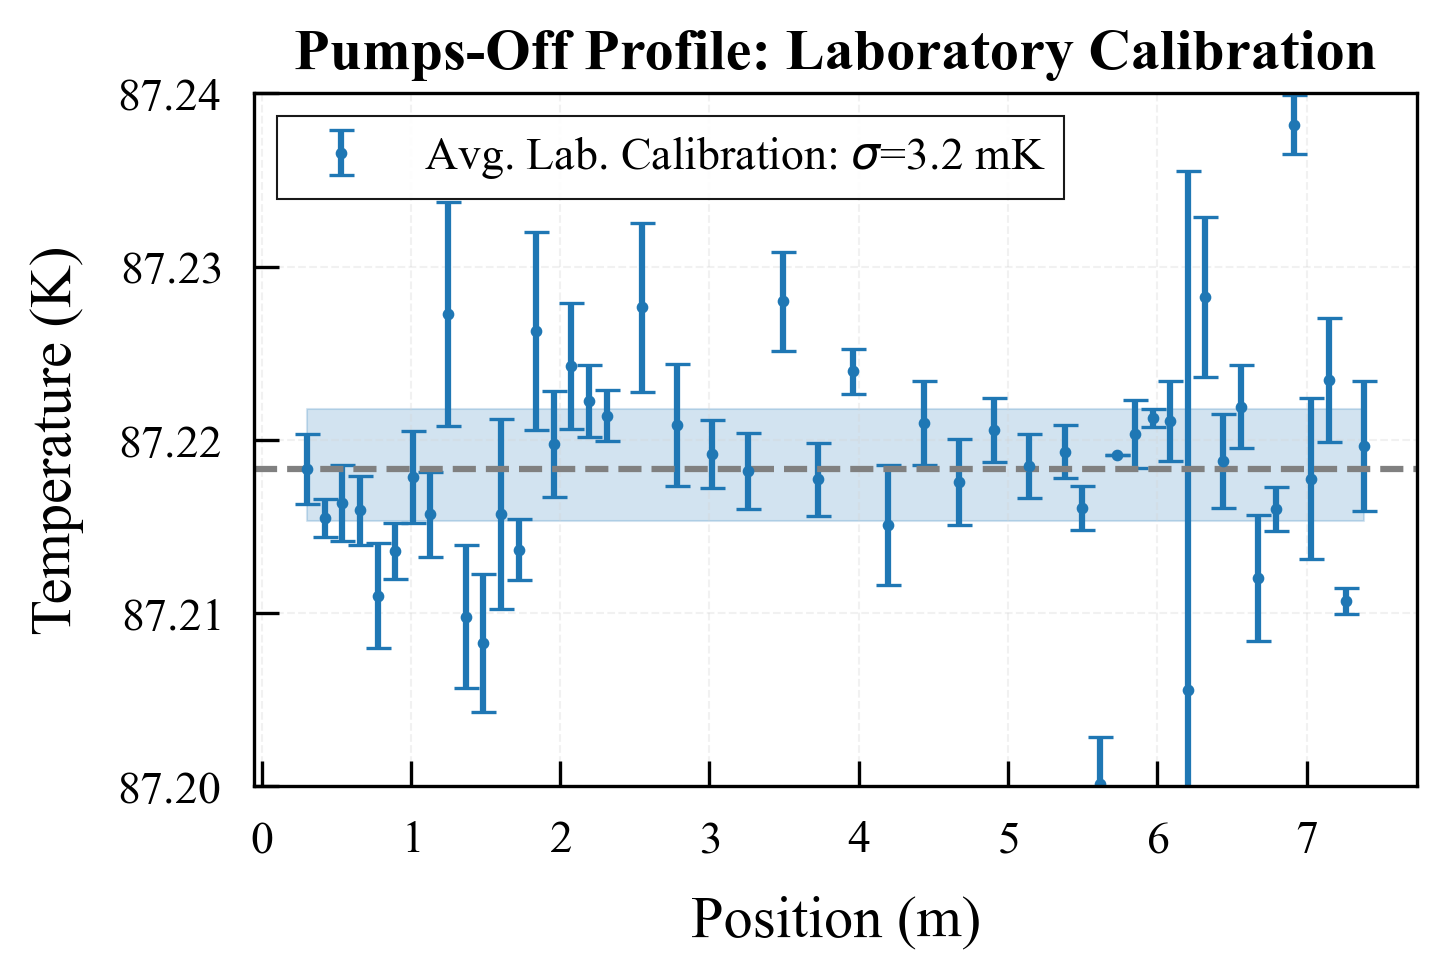

In [ ]:
combined = pd.concat([lar2023["temp"], ln22["temp"], ln23["temp"], lar2018["temp"]], axis=1, ignore_index=True)

fig, axes = plt.subplots()

axes.errorbar(
    1e-3*lar2023.index.values,
    combined.mean(axis=1).values,
    yerr=combined.std(axis=1).values,
    fmt=".",
    label=fr"Avg. Lab. Calibration: $\sigma$={1e3*combined.std(axis=1).mean():.1f} mK",
    color="tab:blue"
)

axes.axhline(combined.mean(axis=1).values[-1], color='gray', linestyle='--')
axes.fill_between(
    1e-3*lar2023.index.values,
    combined.mean(axis=1).mean() - combined.std(axis=1).mean(),
    combined.mean(axis=1).mean() + combined.std(axis=1).mean(),
    color='tab:blue',
    alpha=0.2,
)

# axes.errorbar(
#     1e-3*lar2023.index.values,
#     (combined.mean(axis=1).values + (hp_profile["temp"] - hp_profile["temp"].values[-1])).values,
#     yerr=combined.std(axis=1).values,
#     fmt=".",
#     label="coombined",
#     color="tab:orange"
# )

axes.set_ylim(87.20, 87.24)
axes.set_xlabel("Position (m)")
axes.set_ylabel("Temperature (K)")
axes.set_title("Pumps-Off Profile: Laboratory Calibration")
fig.set_size_inches(5,3)
plt.legend()

In [162]:
import numpy as np
from scipy.optimize import curve_fit

# 1. Your data
data = combined.mean(axis=1).values - combined.mean(axis=1).mean()

# 2. Histogram (without plotting yet)
counts, bin_edges = np.histogram(data, bins=20, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# 3. Gaussian model
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# 4. Initial guesses
A0  = counts.max()
mu0 = data.mean()
s0  = data.std()

# 5. Fit
popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=[A0, mu0, s0])
A_fit, mu_fit, sigma_fit = popt


/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_64149/1734303239.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=[A0, mu0, s0])


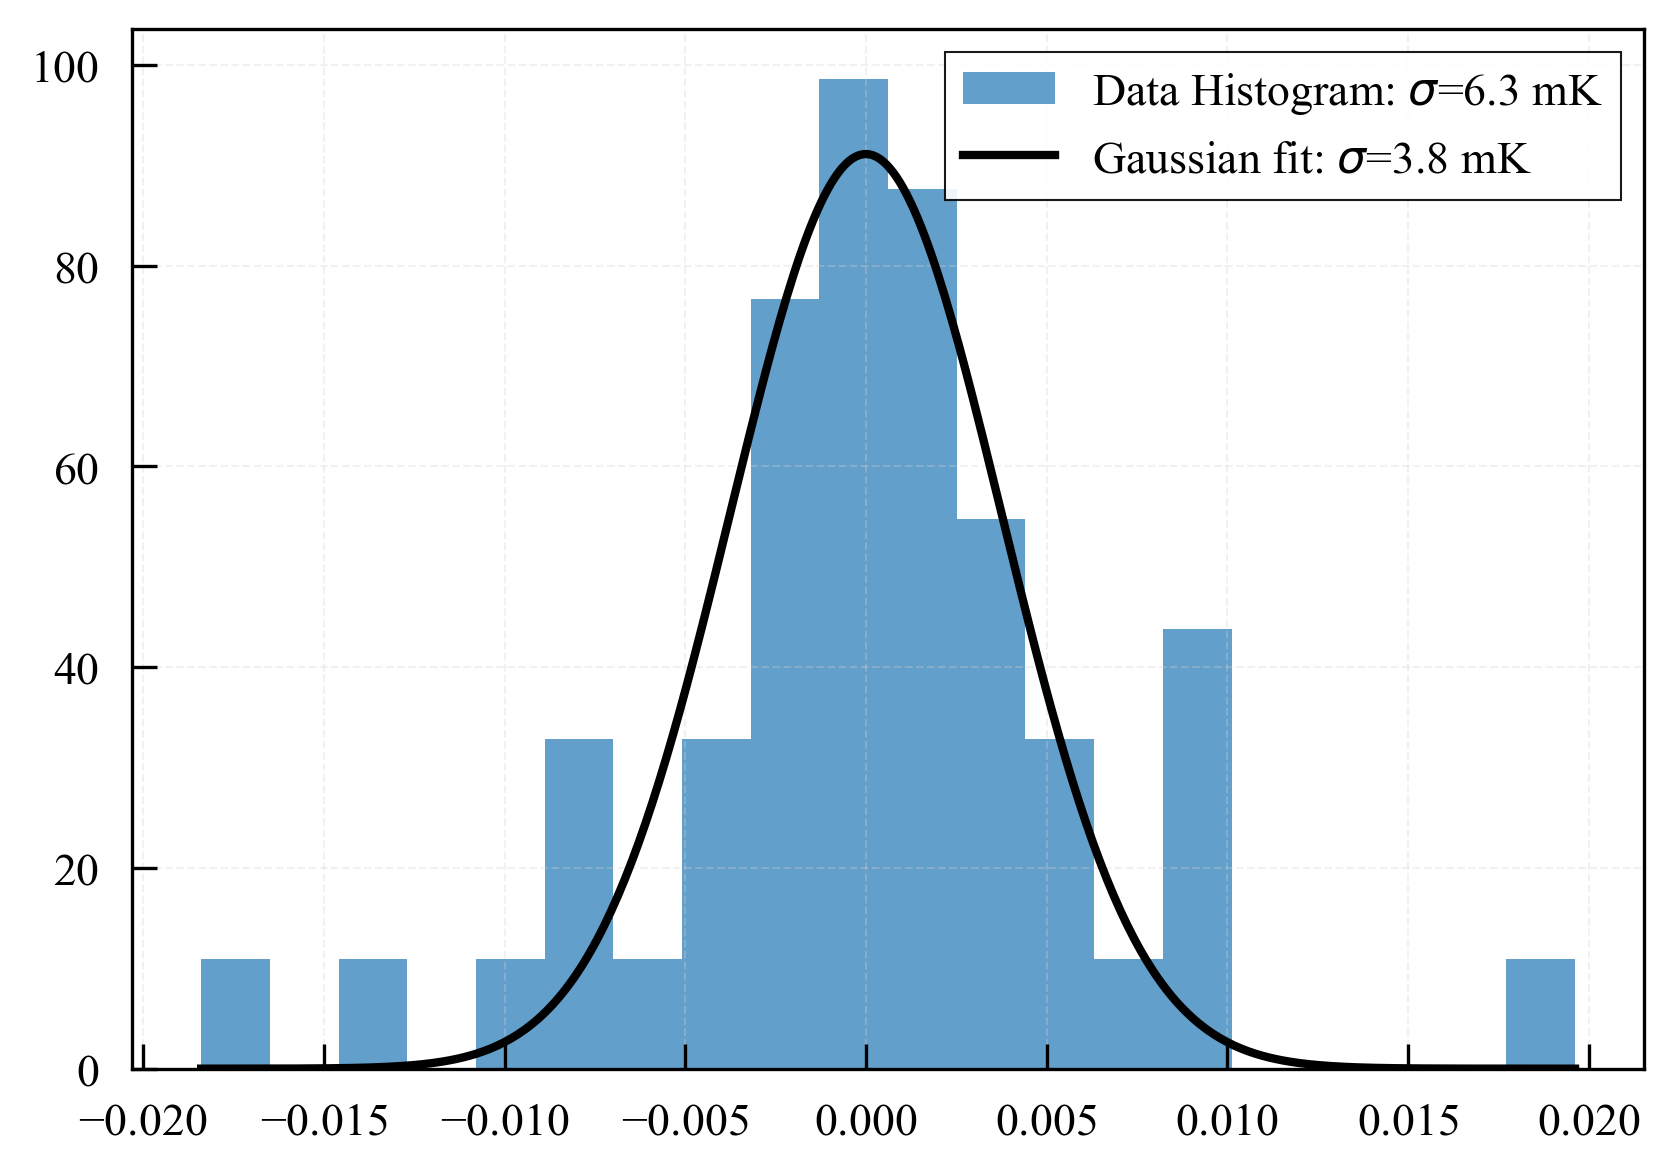

In [166]:
fig, axes = plt.subplots()
axes.hist(
    data,
    bins=20,
    density=True,
    histtype="stepfilled",
    alpha=0.7,
    color="tab:blue",
    label=fr"Data Histogram: $\sigma$={1e3*data.std():.1f} mK"
)

# Gaussian curve
x = np.linspace(data.min(), data.max(), 400)
axes.plot(
    x,
    gaussian(x, *popt),
    color="black",
    linewidth=2,
    label=fr"Gaussian fit: $\sigma$={1e3*sigma_fit:.1f} mK"
)

axes.legend()
